# OTT Streaming Content Trend Analysis

### Netflix Movies & TV Shows

**Project Type:** Data Analytics / Exploratory Data Analysis (EDA)

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQL, Excel

---

## Project Overview

This project analyzes an OTT streaming content catalog to identify trends in content type, genres, release years, ratings, countries, and content additions over time.

The analysis aims to generate data-driven insights that can support content strategy and acquisition decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Dataset Description

The dataset used for this project is the **Netflix Movies and TV Shows dataset**.

The dataset contains information about titles available on the Netflix streaming platf
## Load Dataset

The raw Netflix dataset is loaded into a Pandas DataFrame for further analysisiption of the title |

In [42]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Missing Percentage
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print("Duplicate show IDs:", df["show_id"].duplicated().sum())

Duplicate show IDs: 0


In [12]:
df_clean = df.copy()

In [13]:
df_clean = df_clean.drop_duplicates()

In [14]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

In [15]:
df_clean["added_year"] = df_clean["date_added"].dt.year
df_clean["added_month"] = df_clean["date_added"].dt.month

In [16]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [17]:
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")

In [18]:
df_clean["rating"] = df_clean["rating"].fillna("Unknown")

In [19]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
added_year      98
added_month     98
dtype: int64

In [20]:
df_clean.to_csv(
    "../data/cleaned/netflix_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
content_type = df_clean["type"].value_counts()

content_type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

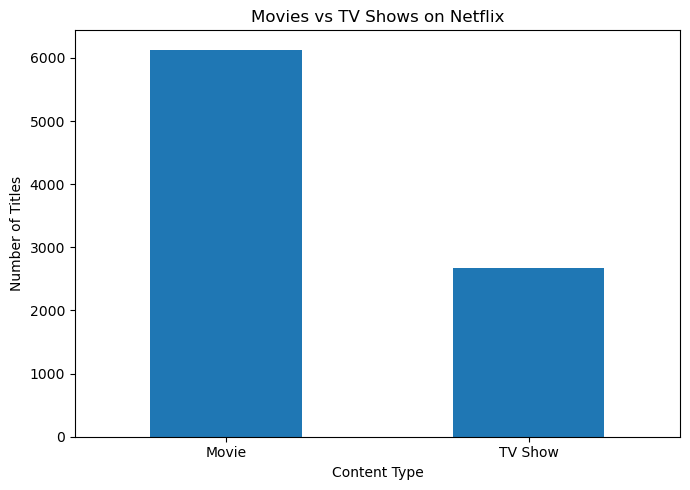

In [22]:
plt.figure(figsize=(7,5))

content_type.plot(
    kind="bar"
)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [25]:
plt.savefig(
    "../visualizations/movies_vs_tv_shows.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

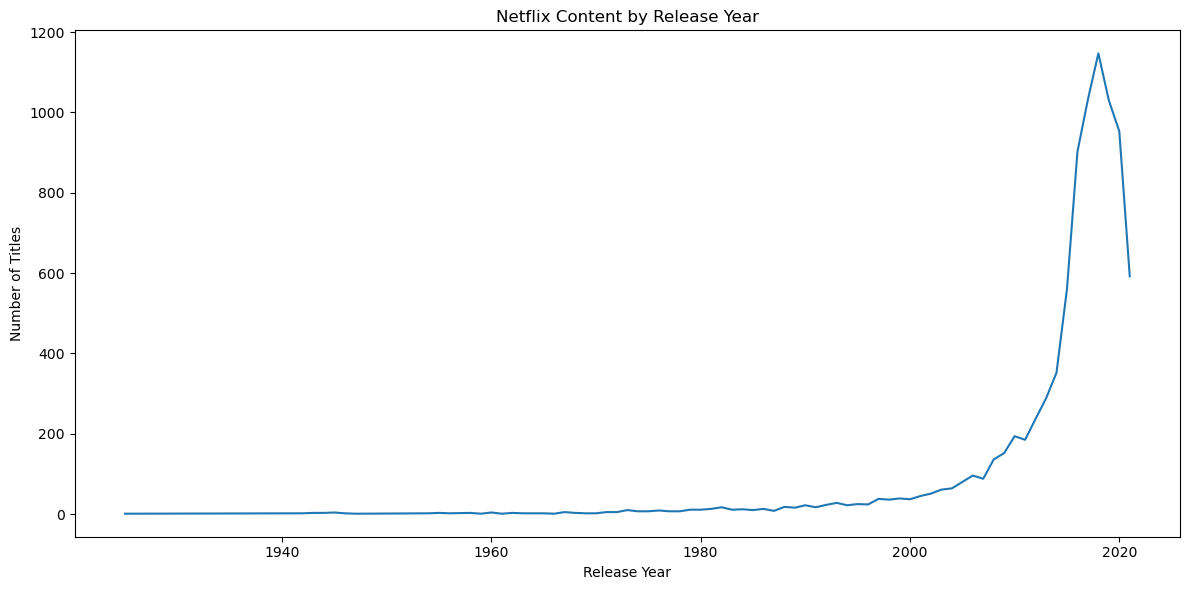

In [26]:
yearly_content = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly_content.index,
    yearly_content.values
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [27]:
plt.savefig(
    "../visualizations/content_by_release_year.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [28]:
genres = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

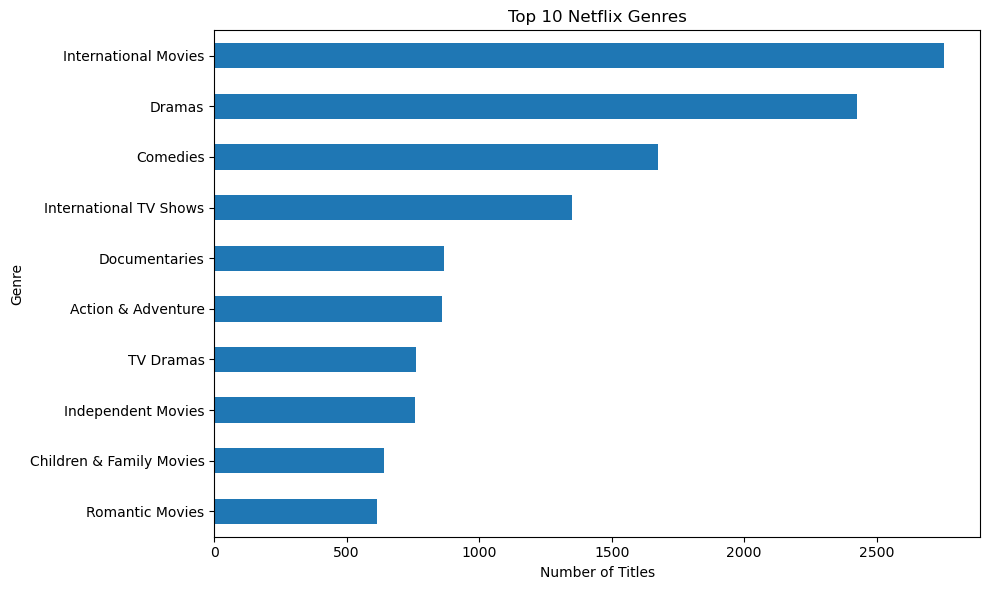

In [29]:
plt.figure(figsize=(10,6))

top_genres.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [30]:
plt.savefig(
    "../visualizations/top_10_genres.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

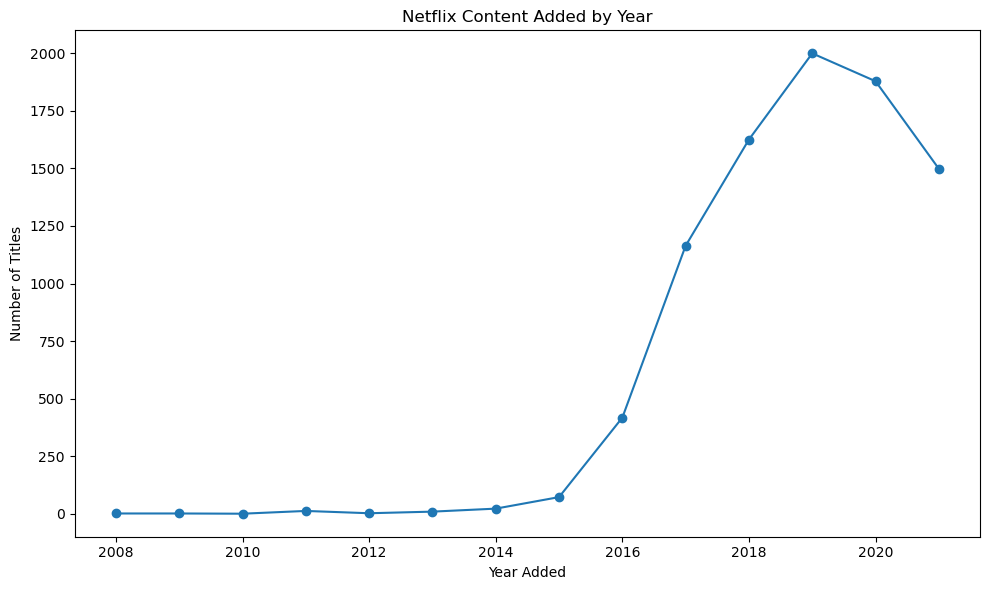

In [31]:
content_added_year = (
    df_clean["added_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.plot(
    content_added_year.index,
    content_added_year.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [32]:
plt.savefig(
    "../visualizations/content_added_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [33]:
countries = (
    df_clean["country"]
    .str.split(", ")
    .explode()
)

top_countries = countries.value_counts().head(10)

top_countries

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

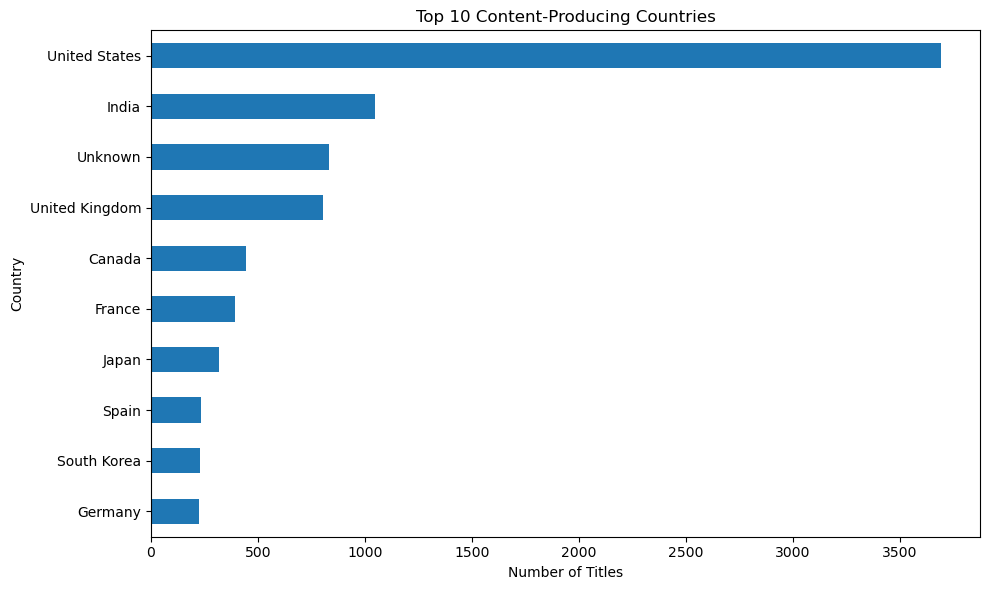

In [34]:
plt.figure(figsize=(10,6))

top_countries.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [35]:
plt.savefig(
    "../visualizations/top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [36]:
type_year = (
    df_clean
    .groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)

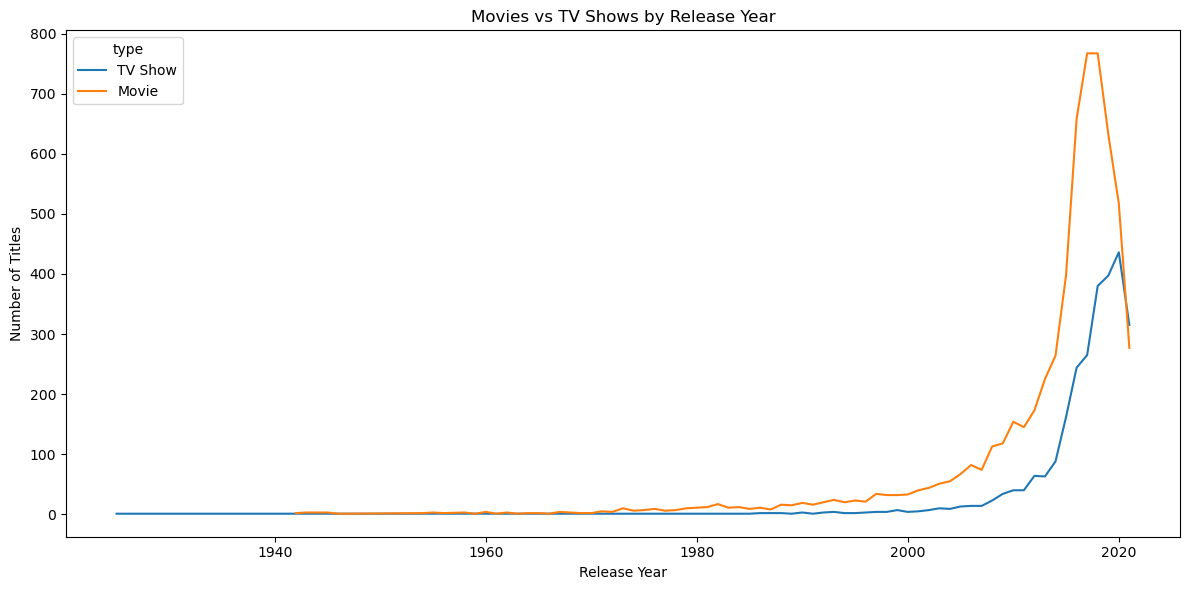

In [37]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=type_year,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [38]:
plt.savefig(
    "../visualizations/movies_vs_tv_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

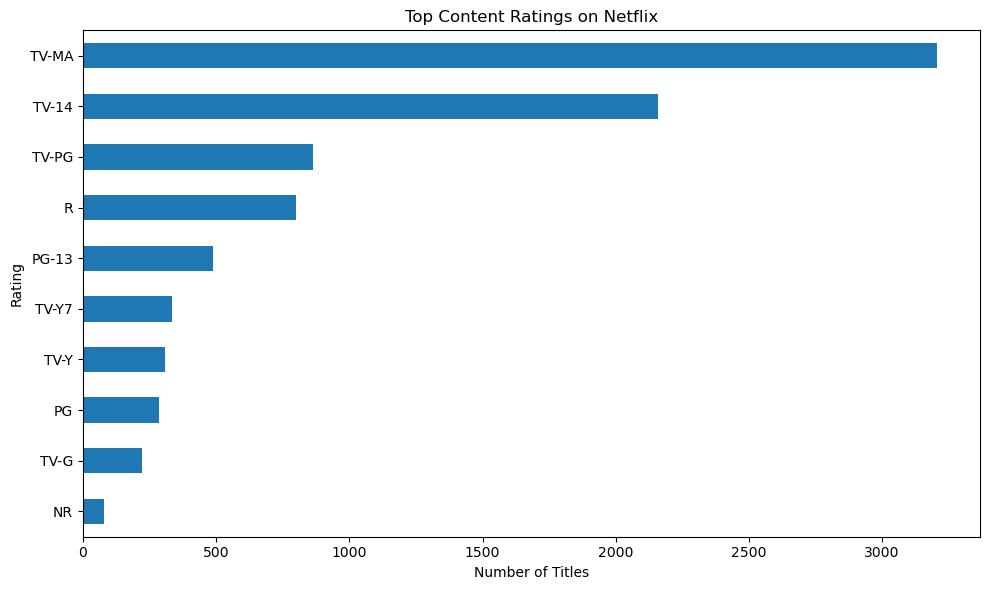

In [39]:
rating_counts = df_clean["rating"].value_counts().head(10)

plt.figure(figsize=(10,6))

rating_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [40]:
plt.savefig(
    "../visualizations/content_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Initial Business Insights

1. Netflix's catalog contains both Movies and TV Shows, with Movies representing a substantial share of the available titles.

2. The distribution of titles by release year shows a strong concentration of relatively recent content, indicating the importance of modern content acquisition.

3. Drama, International Movies, Comedy and related genres form major portions of the catalog, suggesting strong demand for diverse entertainment categories.

4. The country analysis shows that Netflix's catalog is geographically diverse, with content originating from multiple major production markets.

5. Content additions vary significantly by year, indicating periods of accelerated catalog expansion.

6. The rating distribution indicates that Netflix's catalog serves multiple audience segments, including children, teenagers and adults.